<a href="https://colab.research.google.com/github/Rabin-2468/Artificial-Intelligence-and-Machine-Learning/blob/main/workshop4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise: FCN for Devnagari Digit Classification

# 1. Set dataset paths

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

train_dir = "/content/drive/MyDrive/AI and Machine learning/workshop4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI and Machine learning/workshop4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test"

img_height, img_width = 28, 28
num_classes = 10
batch_size = 128
epochs = 20

# 2. Function to load images from folders

In [ ]:
def load_images_from_folder(folder, img_size=(28, 28)):
    images = []
    labels = []

    # Sort class folders so digit_0 -> 0, digit_1 -> 1, ...
    class_names = sorted(
        [d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))]
    )
    class_map = {class_name: idx for idx, class_name in enumerate(class_names)}

    print(f"\nLoading data from: {folder}")
    print("Class mapping:", class_map)

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            file_path = os.path.join(class_path, filename)

            try:
                img = Image.open(file_path).convert("L")   # grayscale
                img = img.resize(img_size)                 # resize to 28x28
                img = np.array(img, dtype=np.float32) / 255.0  # normalize to [0,1]

                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Skipping {file_path}: {e}")

    return np.array(images), np.array(labels)

# 3. Load training and testing data

In [ ]:
x_train, y_train = load_images_from_folder(train_dir, (img_width, img_height))
x_test, y_test = load_images_from_folder(test_dir, (img_width, img_height))

print("\nOriginal Shapes:")
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)


Loading data from: /content/drive/MyDrive/AI and Machine learning/workshop4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}

Loading data from: /content/drive/MyDrive/AI and Machine learning/workshop4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}

Original Shapes:
x_train: (17007, 28, 28)
y_train: (17007,)
x_test : (3000, 28, 28)
y_test : (3000,)


# 4. Reshape for Keras input
# FCN will use Flatten layer, so keeping shape (28,28,1)

In [ ]:
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("\nReshaped Shapes:")
print("x_train:", x_train.shape)
print("y_train_cat:", y_train_cat.shape)
print("x_test :", x_test.shape)
print("y_test_cat :", y_test_cat.shape)


Reshaped Shapes:
x_train: (17007, 28, 28, 1)
y_train_cat: (17007, 10)
x_test : (3000, 28, 28, 1)
y_test_cat : (3000, 10)


# 5. Visualize sample images

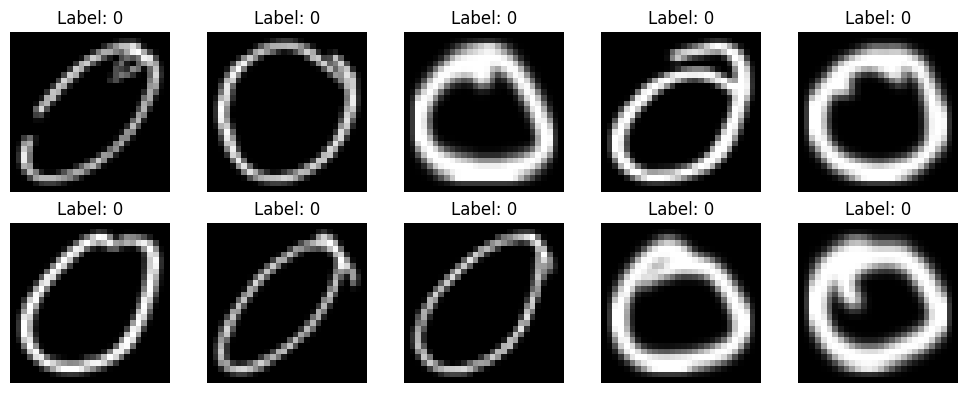

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(min(10, len(x_train))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


# 6. Build the FCN model
# Hidden layers: 64, 128, 256 with sigmoid
# Output layer: 10 with softmax

In [ ]:
model = Sequential([
    Input(shape=(img_height, img_width, 1)),
    Flatten(),
    Dense(64, activation="sigmoid"),
    Dense(128, activation="sigmoid"),
    Dense(256, activation="sigmoid"),
    Dense(num_classes, activation="softmax")
])

print("\nModel Summary:")
model.summary()


Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

# 7. Compile the model
# Since labels are one-hot encoded, categorical_crossentropy is correct.
# If you use integer labels directly, use sparse_categorical_crossentropy.

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# 8. Callbacks

In [ ]:
checkpoint = ModelCheckpoint(
    filepath="best_devnagari_fcn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint, early_stopping]


# 9. Train the model
# validation_split = 0.2
# batch_size = 128
# epochs = 20

In [ ]:
history = model.fit(
    x_train,
    y_train_cat,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3206 - loss: 1.9447
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_devnagari_fcn_model.h5



Epoch 1: finished saving model to best_devnagari_fcn_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5035 - loss: 1.5723 - val_accuracy: 0.0000e+00 - val_loss: 7.5155
Epoch 2/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8113 - loss: 0.5989
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8427 - loss: 0.4857 - val_accuracy: 0.0000e+00 - val_loss: 8.4864
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9110 - loss: 0.3023
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9221 - loss: 0.2687 - val_accuracy: 0.0000e+00 - val_loss: 8.8921
Epoch 4/20
 99/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9432 - loss: 0.1976
Epoch 4: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9457 - loss: 0.1921 - val_accuracy: 0.0000e+00 - val_loss: 8.8670
Epoch 5/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s

# 10. Plot training/validation loss and accuracy

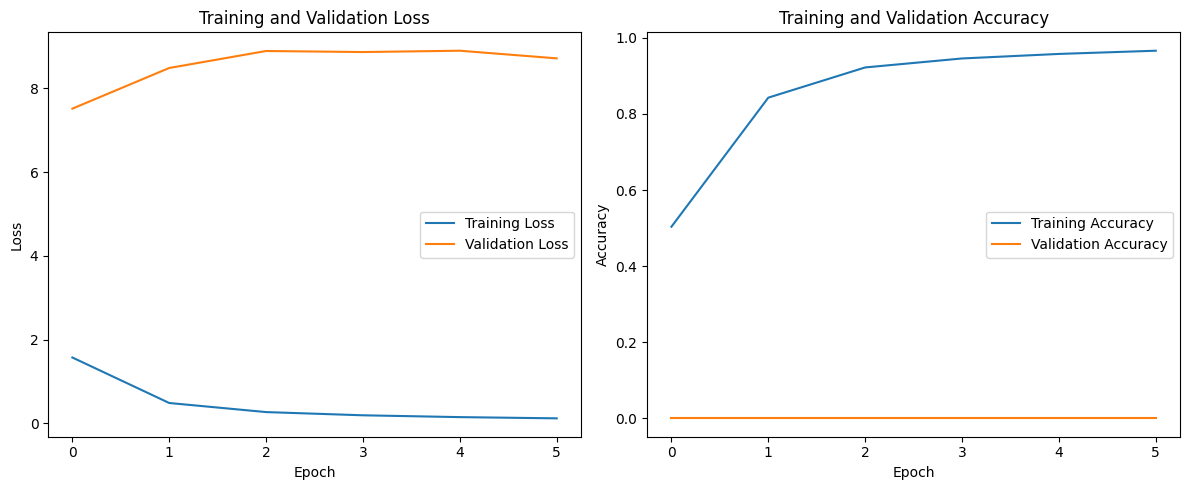

In [ ]:
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# 11. Evaluate the model on test set

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

94/94 - 0s - 2ms/step - accuracy: 0.6247 - loss: 2.1147

Test Loss: 2.1147
Test Accuracy: 0.6247


# 12. Save the final model

In [ ]:
model.save("devnagari_fcn_final_model.h5")
print("\nFinal model saved as: devnagari_fcn_final_model.h5")


Final model saved as: devnagari_fcn_final_model.h5


# 13. Load the saved model and re-evaluate

In [ ]:
loaded_model = tf.keras.models.load_model("devnagari_fcn_final_model.h5")
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test_cat, verbose=2)

print(f"\nLoaded Model Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_acc:.4f}")

94/94 - 1s - 6ms/step - accuracy: 0.6247 - loss: 2.1147

Loaded Model Test Loss: 2.1147
Loaded Model Test Accuracy: 0.6247


# 14. Make predictions

In [ ]:
predictions = loaded_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test_cat, axis=1)

print("\nFirst 10 Predictions:")
for i in range(min(10, len(predicted_labels))):
    print(f"Image {i+1}: Predicted = {predicted_labels[i]}, True = {true_labels[i]}")


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

First 10 Predictions:
Image 1: Predicted = 0, True = 0
Image 2: Predicted = 0, True = 0
Image 3: Predicted = 0, True = 0
Image 4: Predicted = 0, True = 0
Image 5: Predicted = 0, True = 0
Image 6: Predicted = 0, True = 0
Image 7: Predicted = 0, True = 0
Image 8: Predicted = 0, True = 0
Image 9: Predicted = 0, True = 0
Image 10: Predicted = 0, True = 0


# 15. Visualize some predictions

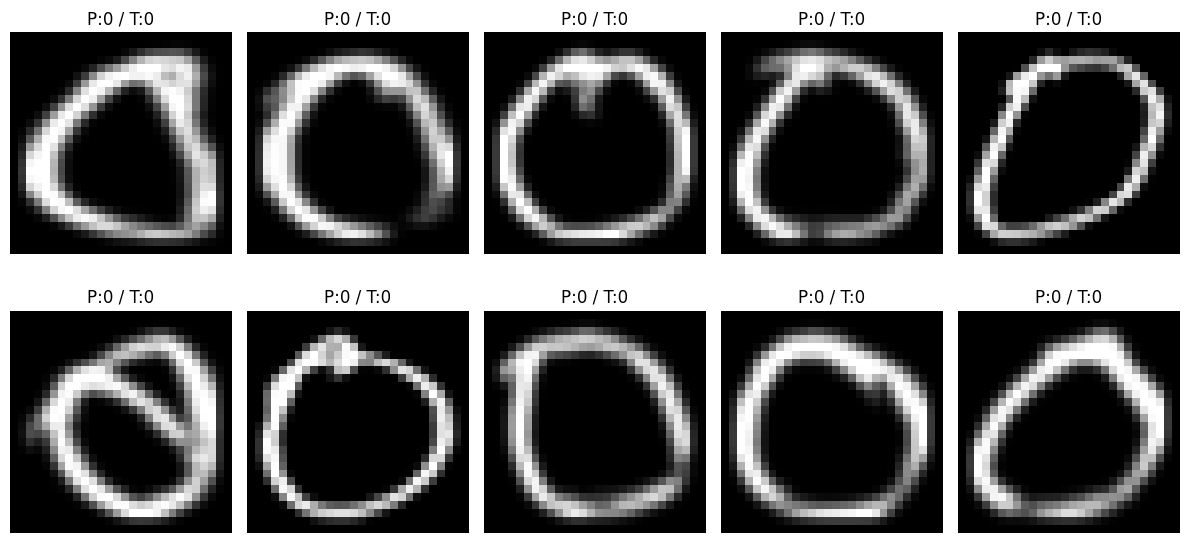

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(min(10, len(x_test))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"P:{predicted_labels[i]} / T:{true_labels[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()